# Superstore Sales — Exploratory Data Analysis
**Dataset:** Sample Superstore (9,994 US retail orders, 2014–2017)  
**Goal:** Understand structure, distributions, relationships, and data quality before ETL.

## 1. Setup & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RAW_PATH = '../data/raw/superstore.csv'

df = pd.read_csv(RAW_PATH, parse_dates=['Order Date', 'Ship Date'], encoding='latin-1')
print(f'Shape: {df.shape}')
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Schema & Data Types

In [3]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## 3. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df[missing_df.missing_count > 0] if missing_df.missing_count.sum() > 0 else print('No missing values found.')

No missing values found.


## 4. Duplicates

In [6]:
n_dupes = df.duplicated().sum()
print(f'Full duplicate rows: {n_dupes}')

# Row ID should be unique
print(f'Unique Row IDs: {df["Row ID"].nunique()} / {len(df)}')

# Order IDs can repeat (multiple products per order)
print(f'Unique Order IDs: {df["Order ID"].nunique()}')

Full duplicate rows: 0
Unique Row IDs: 9994 / 9994
Unique Order IDs: 5009


## 5. Basic Statistics

In [7]:
df.describe().round(2)

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.38,229.86,3.79,0.16,28.66
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.00,209.94,5.00,0.20,29.36
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,22638.48,14.00,0.80,8399.98
std,2885.16,NaN,NaN,32063.69,623.25,2.23,0.21,234.26


In [8]:
# Categorical column cardinality
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col:20s}  unique={df[col].nunique():>6}  sample={df[col].unique()[:3]}')

Order ID              unique=  5009  sample=['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966']
Ship Mode             unique=     4  sample=['Second Class' 'Standard Class' 'First Class']
Customer ID           unique=   793  sample=['CG-12520' 'DV-13045' 'SO-20335']
Customer Name         unique=   793  sample=['Claire Gute' 'Darrin Van Huff' "Sean O'Donnell"]
Segment               unique=     3  sample=['Consumer' 'Corporate' 'Home Office']
Country               unique=     1  sample=['United States']
City                  unique=   531  sample=['Henderson' 'Los Angeles' 'Fort Lauderdale']
State                 unique=    49  sample=['Kentucky' 'California' 'Florida']
Region                unique=     4  sample=['South' 'West' 'Central']
Product ID            unique=  1862  sample=['FUR-BO-10001798' 'FUR-CH-10000454' 'OFF-LA-10000240']
Category              unique=     3  sample=['Furniture' 'Office Supplies' 'Technology']
Sub-Category          unique=    17  sample=['Bookcases' 'Chai

## 6. Date Range & Order Frequency

In [9]:
print(f'Order Date range: {df["Order Date"].min().date()}  →  {df["Order Date"].max().date()}')
print(f'Ship Date range:  {df["Ship Date"].min().date()}  →  {df["Ship Date"].max().date()}')

# Derive shipping lag
df['Ship Lag (days)'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f'\nShip lag — min: {df["Ship Lag (days)"].min()}  max: {df["Ship Lag (days)"].max()}  mean: {df["Ship Lag (days)"].mean():.1f}')

Order Date range: 2014-01-03  →  2017-12-30
Ship Date range:  2014-01-07  →  2018-01-05

Ship lag — min: 0  max: 7  mean: 4.0


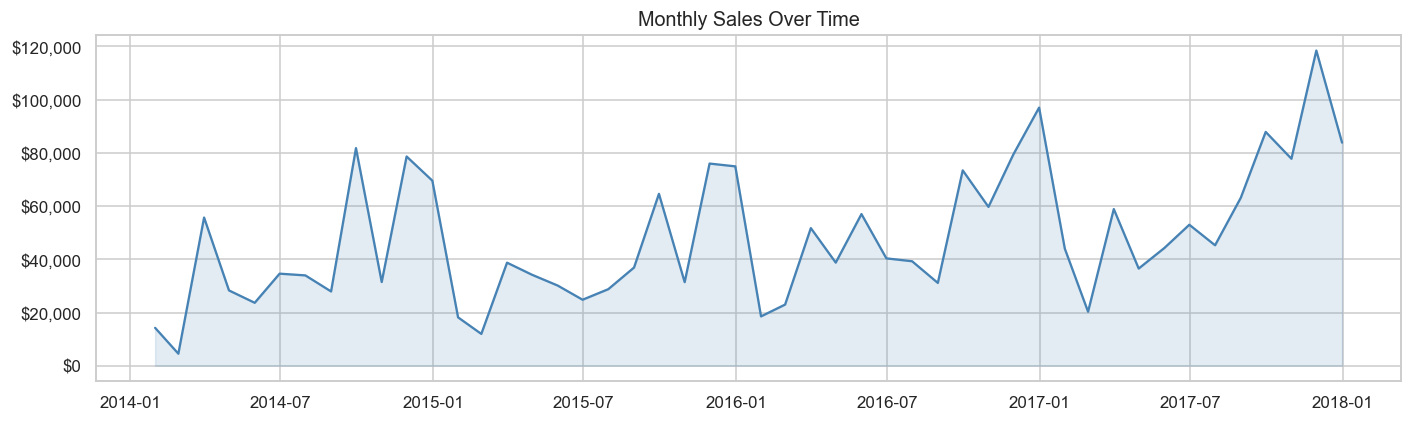

In [10]:
monthly = df.set_index('Order Date').resample('M')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['Order Date'], monthly['Sales'], linewidth=1.5, color='steelblue')
ax.fill_between(monthly['Order Date'], monthly['Sales'], alpha=0.15, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly Sales Over Time', fontsize=13)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 7. Sales, Profit & Discount Distributions

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['Sales', 'Profit', 'Discount'], ['steelblue', 'seagreen', 'coral']):
    data = df[col]
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    sns.histplot(data.clip(lo, hi), ax=ax, kde=True, color=color, bins=50)
    ax.set_title(f'{col} Distribution (1st–99th percentile)')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [12]:
# Orders with negative profit (loss-making)
loss = df[df['Profit'] < 0]
print(f'Loss-making rows: {len(loss)} ({len(loss)/len(df)*100:.1f}%)')
print(f'Total loss: ${loss["Profit"].sum():,.2f}')
print(f'\nLoss by category:')
print(loss.groupby('Category')['Profit'].sum().round(2))

Loss-making rows: 1871 (18.7%)
Total loss: $-156,131.29

Loss by category:
Category
Furniture         -60936.11
Office Supplies   -56615.26
Technology        -38579.92
Name: Profit, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

loss_cat = df[df['Profit'] < 0].groupby('Category')['Profit'].sum().sort_values()
loss_cat.plot(kind='bar', ax=axes[0],
              color=['crimson' if x < 0 else 'steelblue' for x in loss_cat], rot=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('Total Loss by Category')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('')

loss_sub = df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values()
loss_sub.plot(kind='barh', ax=axes[1],
              color=['crimson' if x < 0 else 'steelblue' for x in loss_sub])
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Total Loss by Sub-Category')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 8. Sales & Profit by Category / Sub-Category

In [13]:
cat_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Row ID', 'count')
).round(2)
cat_summary['Profit Margin %'] = (cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100).round(1)
cat_summary

,Total_Sales,Total_Profit,Orders,Profit Margin %
Category,,,,
Furniture,741999.80,18451.27,2121,2.5
Office Supplies,719047.03,122490.80,6026,17.0
Technology,836154.03,145454.95,1847,17.4


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_summary[['Total_Sales', 'Total_Profit']].plot(kind='bar', ax=axes[0], rot=15, color=['steelblue', 'seagreen'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('Sales & Profit by Category')
axes[0].set_xlabel('')

cat_summary['Profit Margin %'].plot(kind='bar', ax=axes[1], color='coral', rot=15)
axes[1].set_title('Profit Margin % by Category')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

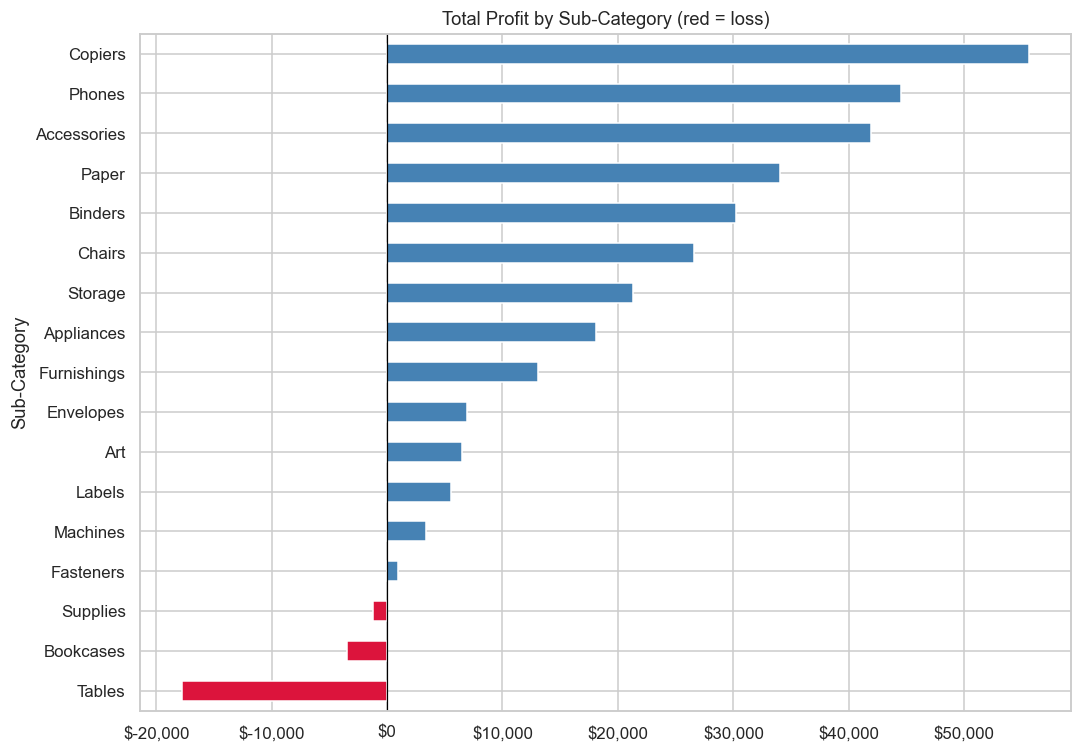

In [14]:
sub_summary = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Profit', ascending=True).round(2)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['crimson' if x < 0 else 'steelblue' for x in sub_summary['Total_Profit']]
sub_summary['Total_Profit'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Total Profit by Sub-Category (red = loss)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Segment & Region Analysis

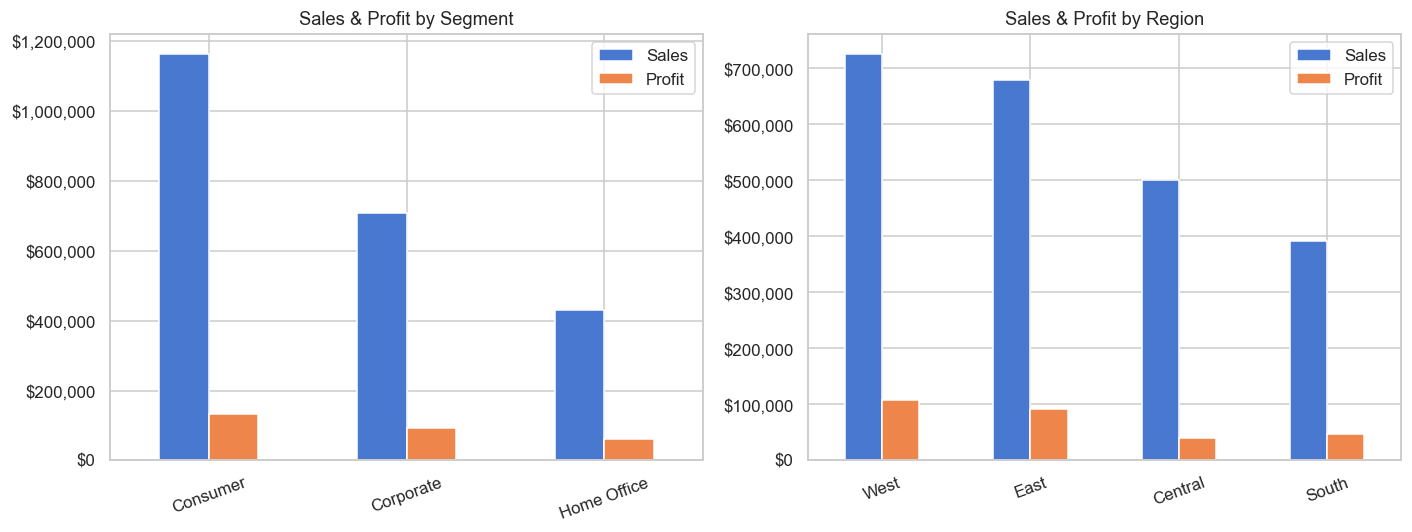

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['Segment', 'Region']):
    grp = df.groupby(col)[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    grp.plot(kind='bar', ax=ax, rot=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(f'Sales & Profit by {col}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 10. Discount vs Profit Relationship

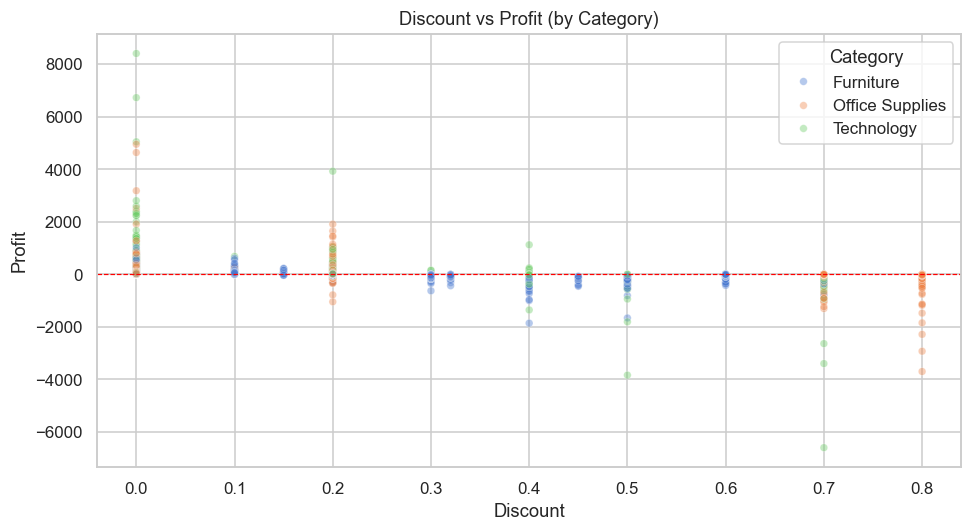


Correlation matrix:
                 Sales  Profit  Discount  Quantity  Ship Lag (days)
Sales            1.000   0.479    -0.028     0.201           -0.007
Profit           0.479   1.000    -0.219     0.066           -0.005
Discount        -0.028  -0.219     1.000     0.009            0.000
Quantity         0.201   0.066     0.009     1.000            0.018
Ship Lag (days) -0.007  -0.005     0.000     0.018            1.000


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=df, x='Discount', y='Profit',
    hue='Category', alpha=0.4, s=25, ax=ax
)
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.set_title('Discount vs Profit (by Category)')
plt.tight_layout()
plt.show()

corr = df[['Sales', 'Profit', 'Discount', 'Quantity', 'Ship Lag (days)']].corr()
print('\nCorrelation matrix:')
print(corr.round(3))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 11. Top States by Sales

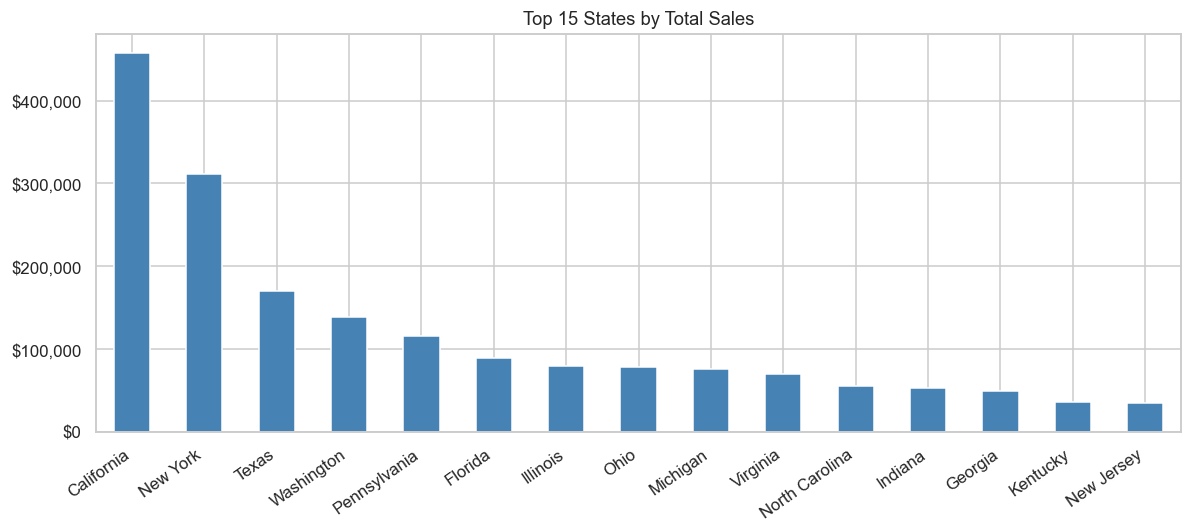

In [17]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
top_states.plot(kind='bar', ax=ax, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 15 States by Total Sales')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 12. Ship Mode Distribution

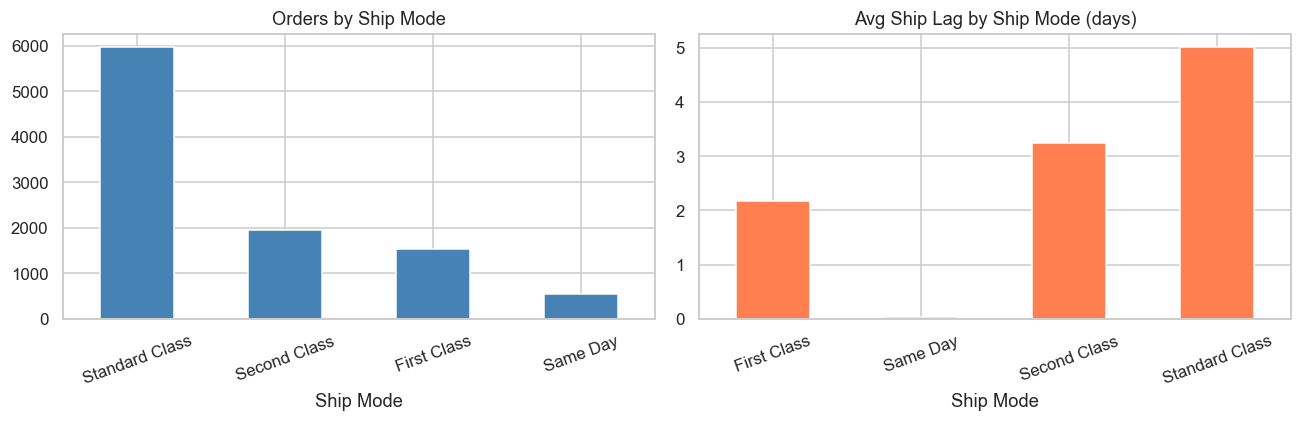

In [18]:
ship_counts = df['Ship Mode'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ship_counts.plot(kind='bar', ax=axes[0], color='steelblue', rot=20)
axes[0].set_title('Orders by Ship Mode')

df.groupby('Ship Mode')['Ship Lag (days)'].mean().plot(kind='bar', ax=axes[1], color='coral', rot=20)
axes[1].set_title('Avg Ship Lag by Ship Mode (days)')

plt.tight_layout()
plt.show()

## 13. EDA Summary — Data Quality Notes

After exploring the dataset, document findings here before moving to ETL.

In [ ]:
print('='*55)
print('EDA SUMMARY')
print('='*55)
print(f'Rows: {len(df):,}    Columns: {df.shape[1]}')
print(f'Date range: {df["Order Date"].min().date()} — {df["Order Date"].max().date()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Negative profit rows: {(df["Profit"] < 0).sum()} ({(df["Profit"] < 0).mean()*100:.1f}%)')
print(f'Unique customers: {df["Customer ID"].nunique()}')
print(f'Unique products: {df["Product ID"].nunique()}')
print(f'States covered: {df["State"].nunique()}')